<a href="https://colab.research.google.com/github/Arunkumarpremsai/my-travel-chronicle/blob/main/Aus_Apparel_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AAL Q4 2020 — Sales & Marketing Analytics Report
# **Goal:**
* Identify high/low revenue states and demographic groups.
* Surface time-of-day patterns.
* Generate periodic reports to guide expansion investments.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120


# Load Data
df_raw = pd.read_csv('AusApparalSales4thQrt2020.csv')
print(df_raw.head())

         Date        Time State     Group  Unit  Sales
0  1-Oct-2020     Morning    WA      Kids     8  20000
1  1-Oct-2020     Morning    WA       Men     8  20000
2  1-Oct-2020     Morning    WA     Women     4  10000
3  1-Oct-2020     Morning    WA   Seniors    15  37500
4  1-Oct-2020   Afternoon    WA      Kids     3   7500



#  Inspect Missing & Incorrect Entries




In [2]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


# **Finding:** No missing values exist in this dataset.
* All 7,560 rows are fully populated across all 6 columns.

# **Recommendation:**

*   For numeric columns (Unit, Sales): fill NaN with the

*   Avoid dropping rows as this would create temporal gaps in daily/weekly reports.

*   Only drop rows if >40% of a row's fields are missing.



In [3]:
# Clean & Engineer Features
df = df_raw.copy()


# Parse Date
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%b-%Y')


# Temporal features
df['Month']     = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%b')
df['Week']      = df['Date'].dt.isocalendar().week.astype(int)
df['DOW']       = df['Date'].dt.day_name()
df['Day']       = df['Date'].dt.day

print("Feature-engineered shape:", df.shape)
pd.set_option('display.max_rows', 100)
print(df.dtypes)
print(df.head(3))


Feature-engineered shape: (7560, 11)
Date         datetime64[ns]
Time                 object
State                object
Group                object
Unit                  int64
Sales                 int64
Month                 int32
MonthName            object
Week                  int64
DOW                  object
Day                   int32
dtype: object
        Date      Time State   Group  Unit  Sales  Month MonthName  Week  \
0 2020-10-01   Morning    WA    Kids     8  20000     10       Oct    40   
1 2020-10-01   Morning    WA     Men     8  20000     10       Oct    40   
2 2020-10-01   Morning    WA   Women     4  10000     10       Oct    40   

        DOW  Day  
0  Thursday    1  
1  Thursday    1  
2  Thursday    1  


In [4]:
df.describe()

,Date,Unit,Sales,Month,Week,Day
count,7560,7560.000000,7560.000000,7560.000000,7560.000000,7560.000000
mean,2020-11-15 04:00:00.000000256,18.005423,45013.558201,11.000000,46.455556,15.500000
min,2020-10-01 00:00:00,2.000000,5000.000000,10.000000,40.000000,1.000000
25%,2020-10-23 00:00:00,8.000000,20000.000000,10.000000,43.000000,8.000000
50%,2020-11-15 12:00:00,14.000000,35000.000000,11.000000,46.500000,15.500000
75%,2020-12-08 00:00:00,26.000000,65000.000000,12.000000,50.000000,23.000000
max,2020-12-30 00:00:00,65.000000,162500.000000,12.000000,53.000000,30.000000
std,NaN,12.901403,32253.506944,0.816551,3.786662,8.656014



# Normalization
# **Choice: Min-Max Normalization**

* Unit and Sales are right-skewed (max Unit=65, mean=18; max Sales=162,500, mean=45,014).
* Min-Max scales both to [0, 1] — ideal for cross-column and cross-state dashboard comparisons.


In [5]:
# Min-Max Normalization
scaler = MinMaxScaler()
df[['Unit_norm', 'Sales_norm']] = scaler.fit_transform(df[['Unit', 'Sales']])
print(df[['Unit', 'Unit_norm', 'Sales', 'Sales_norm']].head(8))

   Unit  Unit_norm  Sales  Sales_norm
0     8   0.095238  20000    0.095238
1     8   0.095238  20000    0.095238
2     4   0.031746  10000    0.031746
3    15   0.206349  37500    0.206349
4     3   0.015873   7500    0.015873
5    10   0.126984  25000    0.126984
6     3   0.015873   7500    0.015873
7    11   0.142857  27500    0.142857


# GroupBy — Chunking vs Merging

# **Recommendation: Chunking**
# We split by [State, Group] (or [State, Time] etc.),
# apply an aggregation (sum / mean), and combine back.
# This surfaces sub-segment KPIs for the S&M team.

# Merging would be appropriate only if joining an external
# dataset (e.g., state population, store-count lookup table).

In [6]:
# GroupBy Aggregations
state_group = (df.groupby(['State', 'Group'])
                 .agg(Total_Sales=('Sales', 'sum'),
                      Total_Units=('Unit',  'sum'),
                      Avg_Sales  =('Sales', 'mean'),
                      Txn_Count  =('Sales', 'count'))
                 .reset_index()
                 .sort_values('Total_Sales', ascending=False))

print(state_group.to_string(index=False))


State    Group  Total_Sales  Total_Units    Avg_Sales  Txn_Count
  VIC    Women     26482500        10593 98083.333333        270
  VIC      Men     26407500        10563 97805.555556        270
  VIC     Kids     26360000        10544 97629.629630        270
  VIC  Seniors     26315000        10526 97462.962963        270
  NSW    Women     19172500         7669 71009.259259        270
  NSW      Men     19022500         7609 70453.703704        270
  NSW     Kids     18587500         7435 68842.592593        270
  NSW  Seniors     18187500         7275 67361.111111        270
   SA    Women     14970000         5988 55444.444444        270
   SA  Seniors     14717500         5887 54509.259259        270
   SA      Men     14655000         5862 54277.777778        270
   SA     Kids     14515000         5806 53759.259259        270
  QLD     Kids      8510000         3404 31518.518519        270
  QLD      Men      8392500         3357 31083.333333        270
  QLD    Women      83250

#  Data Analysis
* Descriptive Statistics — Sales & Unit

In [7]:
for col in ['Sales', 'Unit']:
    s = df[col]
    mode_val = stats.mode(s, keepdims=True).mode[0]
    print(f"\n{'─'*42}")
    print(f"  {col} — Descriptive Statistics")
    print(f"{'─'*42}")
    print(f"  Count    : {int(s.count()):,}")
    print(f"  Mean     : {s.mean():,.2f}")
    print(f"  Median   : {s.median():,.2f}")
    print(f"  Mode     : {mode_val:,.2f}")
    print(f"  Std Dev  : {s.std():,.2f}")
    print(f"  Variance : {s.var():,.2f}")
    print(f"  Min      : {s.min():,.2f}")
    print(f"  Max      : {s.max():,.2f}")
    print(f"  Skewness : {s.skew():.4f}")
    print(f"  Kurtosis : {s.kurt():.4f}")
    print(f"  Q1 (25%) : {s.quantile(0.25):,.2f}")
    print(f"  Q3 (75%) : {s.quantile(0.75):,.2f}")
    print(f"  IQR      : {s.quantile(0.75) - s.quantile(0.25):,.2f}")



──────────────────────────────────────────
  Sales — Descriptive Statistics
──────────────────────────────────────────
  Count    : 7,560
  Mean     : 45,013.56
  Median   : 35,000.00
  Mode     : 22,500.00
  Std Dev  : 32,253.51
  Variance : 1,040,288,710.18
  Min      : 5,000.00
  Max      : 162,500.00
  Skewness : 1.0856
  Kurtosis : 0.6614
  Q1 (25%) : 20,000.00
  Q3 (75%) : 65,000.00
  IQR      : 45,000.00

──────────────────────────────────────────
  Unit — Descriptive Statistics
──────────────────────────────────────────
  Count    : 7,560
  Mean     : 18.01
  Median   : 14.00
  Mode     : 9.00
  Std Dev  : 12.90
  Variance : 166.45
  Min      : 2.00
  Max      : 65.00
  Skewness : 1.0856
  Kurtosis : 0.6614
  Q1 (25%) : 8.00
  Q3 (75%) : 26.00
  IQR      : 18.00


# Highest & Lowest Sales Groups

In [8]:
state_total = df.groupby('State')['Sales'].sum().reset_index()
print("\n=== Total Sales by State (Q4 2020) ===")
print(state_total.sort_values('Sales', ascending=False).to_string(index=False))
high_state = state_total.loc[state_total['Sales'].idxmax(), 'State']
low_state  = state_total.loc[state_total['Sales'].idxmin(), 'State']
print(f"\n Highest Revenue State : {high_state}")
print(f"   Lowest Revenue State : {low_state}")

group_total = df.groupby('Group')['Sales'].sum().reset_index()
print("\n=== Total Sales by Group (Q4 2020) ===")
print(group_total.sort_values('Sales', ascending=False).to_string(index=False))
high_group = group_total.loc[group_total['Sales'].idxmax(), 'Group']
low_group  = group_total.loc[group_total['Sales'].idxmin(), 'Group']
print(f"\n Highest Revenue Group : {high_group}")
print(f"   Lowest Revenue Group : {low_group}")


=== Total Sales by State (Q4 2020) ===
State     Sales
  VIC 105565000
  NSW  74970000
   SA  58857500
  QLD  33417500
  TAS  22760000
   NT  22580000
   WA  22152500

 Highest Revenue State :  VIC
   Lowest Revenue State :  WA

=== Total Sales by Group (Q4 2020) ===
   Group    Sales
     Men 85750000
   Women 85442500
    Kids 85072500
 Seniors 84037500

 Highest Revenue Group :  Men
   Lowest Revenue Group :  Seniors


#**Periodic Reports**

In [9]:
# Quarterly Report
quarterly = (df.groupby('State')
               .agg(Q4_Sales =('Sales', 'sum'),
                    Q4_Units =('Unit',  'sum'),
                    Avg_Sales_per_Txn=('Sales', 'mean'))
               .reset_index()
               .sort_values('Q4_Sales', ascending=False))
print("\n=== QUARTERLY REPORT — Q4 2020 ===")
print(quarterly.to_string(index=False))




=== QUARTERLY REPORT — Q4 2020 ===
State  Q4_Sales  Q4_Units  Avg_Sales_per_Txn
  VIC 105565000     42226       97745.370370
  NSW  74970000     29988       69416.666667
   SA  58857500     23543       54497.685185
  QLD  33417500     13367       30942.129630
  TAS  22760000      9104       21074.074074
   NT  22580000      9032       20907.407407
   WA  22152500      8861       20511.574074


In [10]:
# Monthly Report
monthly_state = (df.groupby(['Month', 'MonthName', 'State'])['Sales']
                   .sum().reset_index()
                   .sort_values(['Month', 'Sales'], ascending=[True, False]))
print("\n=== MONTHLY REPORT — Q4 2020 ===")
print(monthly_state.to_string(index=False))

monthly_total = (df.groupby(['Month', 'MonthName'])['Sales']
                   .sum().reset_index()
                   .sort_values('Month'))
print("\nMonthly Totals:")
print(monthly_total.to_string(index=False))




=== MONTHLY REPORT — Q4 2020 ===
 Month MonthName State    Sales
    10       Oct   VIC 33442500
    10       Oct   NSW 25007500
    10       Oct    SA 20610000
    10       Oct   QLD 11120000
    10       Oct    NT  8222500
    10       Oct   TAS  8015000
    10       Oct    WA  7872500
    11       Nov   VIC 29530000
    11       Nov   NSW 21490000
    11       Nov    SA 15532500
    11       Nov   QLD  8110000
    11       Nov   TAS  5545000
    11       Nov    NT  5257500
    11       Nov    WA  5217500
    12       Dec   VIC 42592500
    12       Dec   NSW 28472500
    12       Dec    SA 22715000
    12       Dec   QLD 14187500
    12       Dec   TAS  9200000
    12       Dec    NT  9100000
    12       Dec    WA  9062500

Monthly Totals:
 Month MonthName     Sales
    10       Oct 114290000
    11       Nov  90682500
    12       Dec 135330000


In [11]:
# Weekly Report
weekly_total = df.groupby('Week')['Sales'].sum().reset_index()
print("\n=== WEEKLY REPORT — Q4 2020 ===")
print(weekly_total.to_string(index=False))


=== WEEKLY REPORT — Q4 2020 ===
 Week    Sales
   40 15045000
   41 27002500
   42 26640000
   43 26815000
   44 21807500
   45 20865000
   46 21172500
   47 21112500
   48 21477500
   49 29622500
   50 31525000
   51 31655000
   52 31770000
   53 13792500


#**Data Visualization**
# **Library Choice: Seaborn + Matplotlib**
* Seaborn is purpose-built for statistical graphics (distribution plots, box plots, heatmaps).
* DataFrame-native API integrates cleanly with Pandas GroupBy.
* Matplotlib provides fine-grained layout control for multi-panel dashboards.
* Plotly offers interactivity but is harder to embed in JupyterLab PDF exports.
#**Recommendation:**
* Seaborn for statistical plots.
* Matplotlib for composite dashboards.

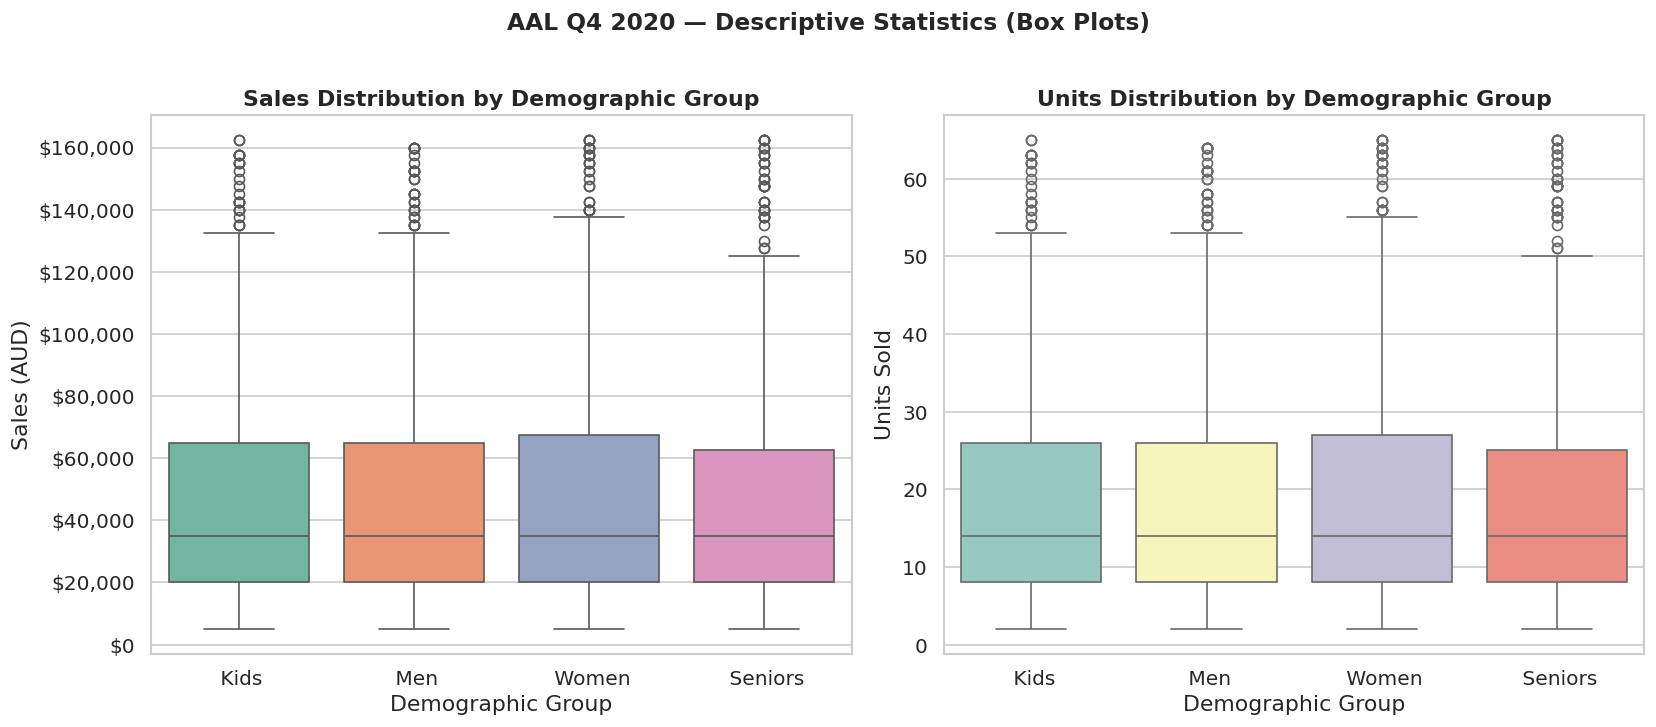

In [16]:
# Box Plot — Descriptive Statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='Group', y='Sales',
            palette='Set2',ax=axes[0])
axes[0].set_title('Sales Distribution by Demographic Group', fontweight='bold')
axes[0].set_xlabel('Demographic Group')
axes[0].set_ylabel('Sales (AUD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.boxplot(data=df, x='Group', y='Unit',
            palette='Set3',ax=axes[1])
axes[1].set_title('Units Distribution by Demographic Group', fontweight='bold')
axes[1].set_xlabel('Demographic Group')
axes[1].set_ylabel('Units Sold')

plt.suptitle('AAL Q4 2020 — Descriptive Statistics (Box Plots)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


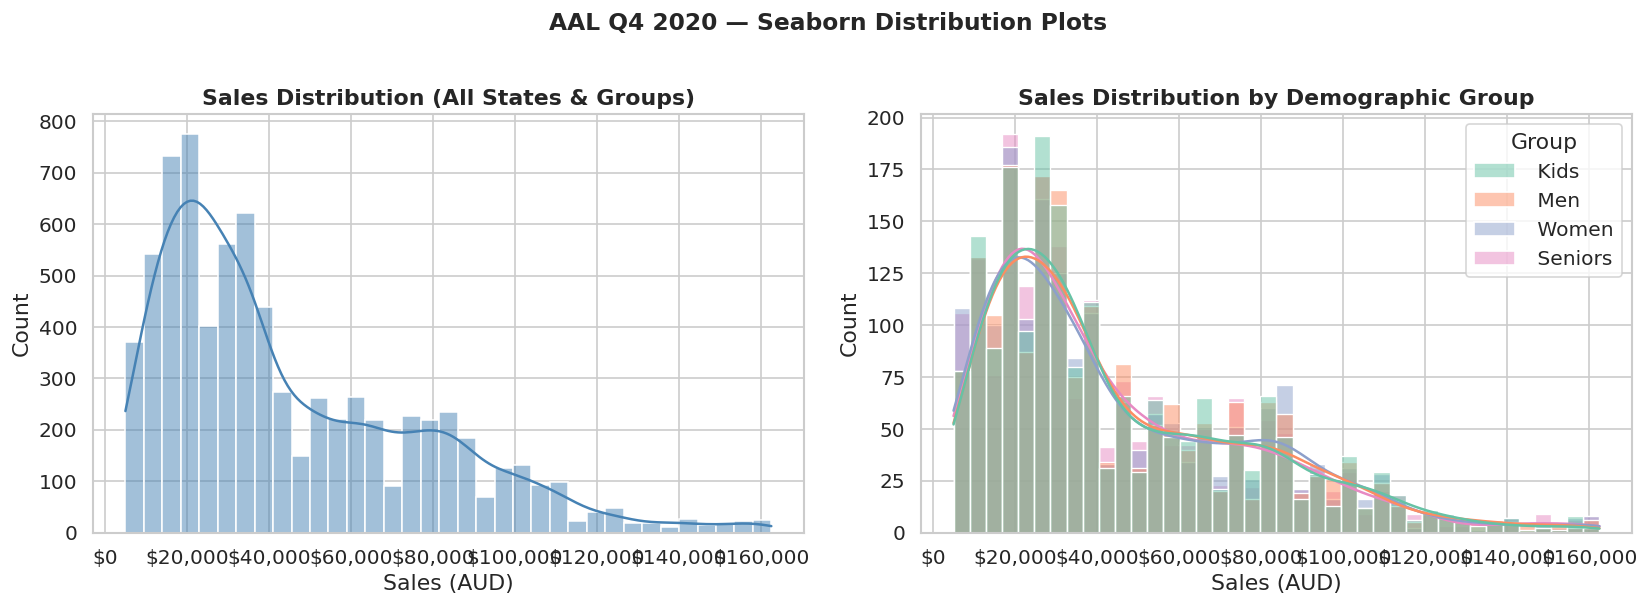

In [23]:
# Seaborn Distribution Plot — Sales & Unit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df, x='Sales', kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Sales Distribution (All States & Groups)', fontweight='bold')
axes[0].set_xlabel('Sales (AUD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.histplot(df, x='Sales', hue='Group', kde=True, palette='Set2', bins= 40,
              ax=axes[1])
axes[1].set_title('Sales Distribution by Demographic Group', fontweight='bold')
axes[1].set_xlabel('Sales (AUD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('AAL Q4 2020 — Seaborn Distribution Plots',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

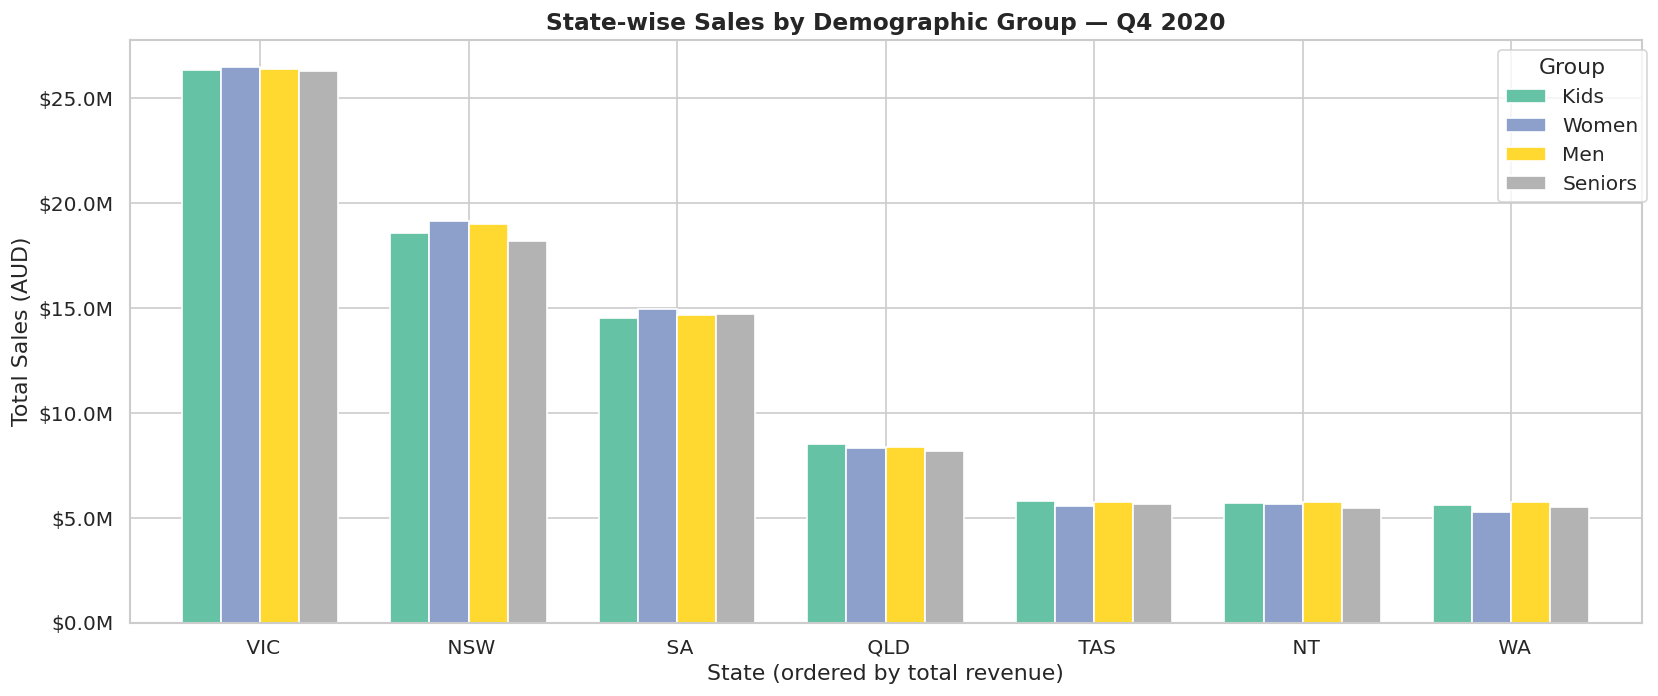

In [29]:
# Helper: state order by revenue descending
state_order = (df.groupby('State')['Sales']
                 .sum().sort_values(ascending=False).index.tolist())

# Clean whitespace from Group names to prevent KeyErrors
df['Group'] = df['Group'].str.strip()

# State-wise Sales by Group (Grouped Bar)
pivot_sg = (df.groupby(['State', 'Group'])['Sales'].sum().unstack()[['Kids','Women','Men','Seniors']])
pivot_sg = pivot_sg.loc[state_order]  # order by revenue

fig, ax = plt.subplots(figsize=(14, 6))
pivot_sg.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.75)
ax.set_title('State-wise Sales by Demographic Group — Q4 2020',
             fontsize=14, fontweight='bold')
ax.set_xlabel('State (ordered by total revenue)')
ax.set_ylabel('Total Sales (AUD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(title='Group', bbox_to_anchor=(1.01, 1))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

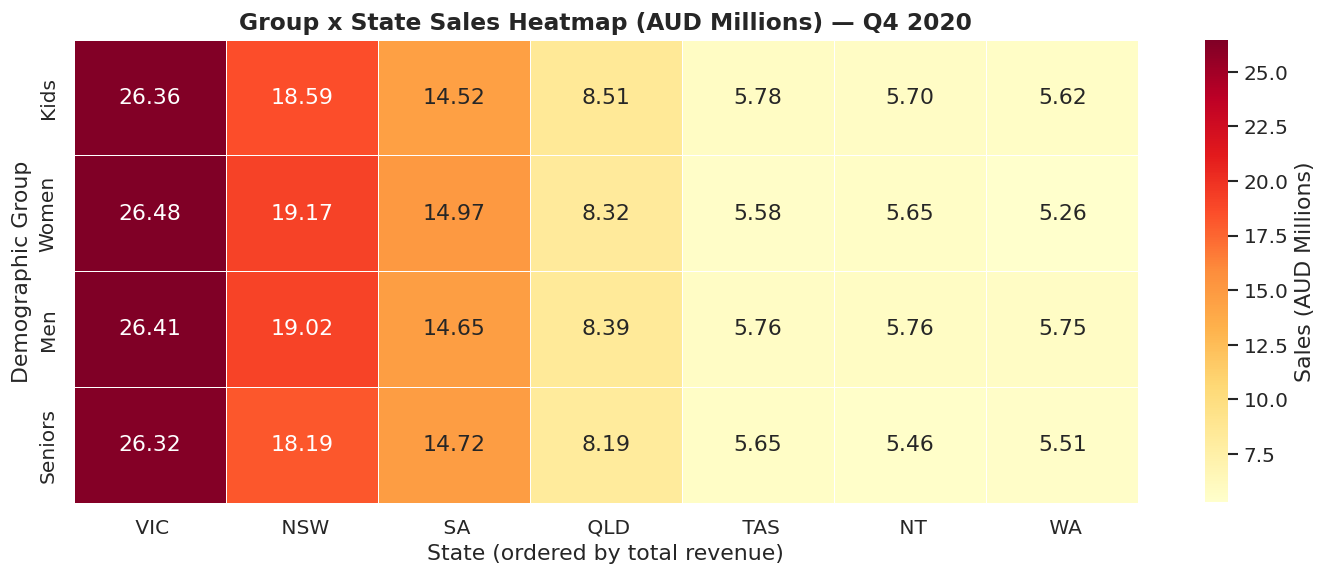

In [31]:
# Group-wise Sales across States (Heatmap)
heat_data = (df.groupby(['Group', 'State'])['Sales']
               .sum().unstack()
               .loc[['Kids','Women','Men','Seniors'], state_order])

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heat_data / 1e6, annot=True, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Sales (AUD Millions)'})
ax.set_title('Group x State Sales Heatmap (AUD Millions) — Q4 2020',
             fontsize=14, fontweight='bold')
ax.set_xlabel('State (ordered by total revenue)')
ax.set_ylabel('Demographic Group')
plt.tight_layout()
plt.show()

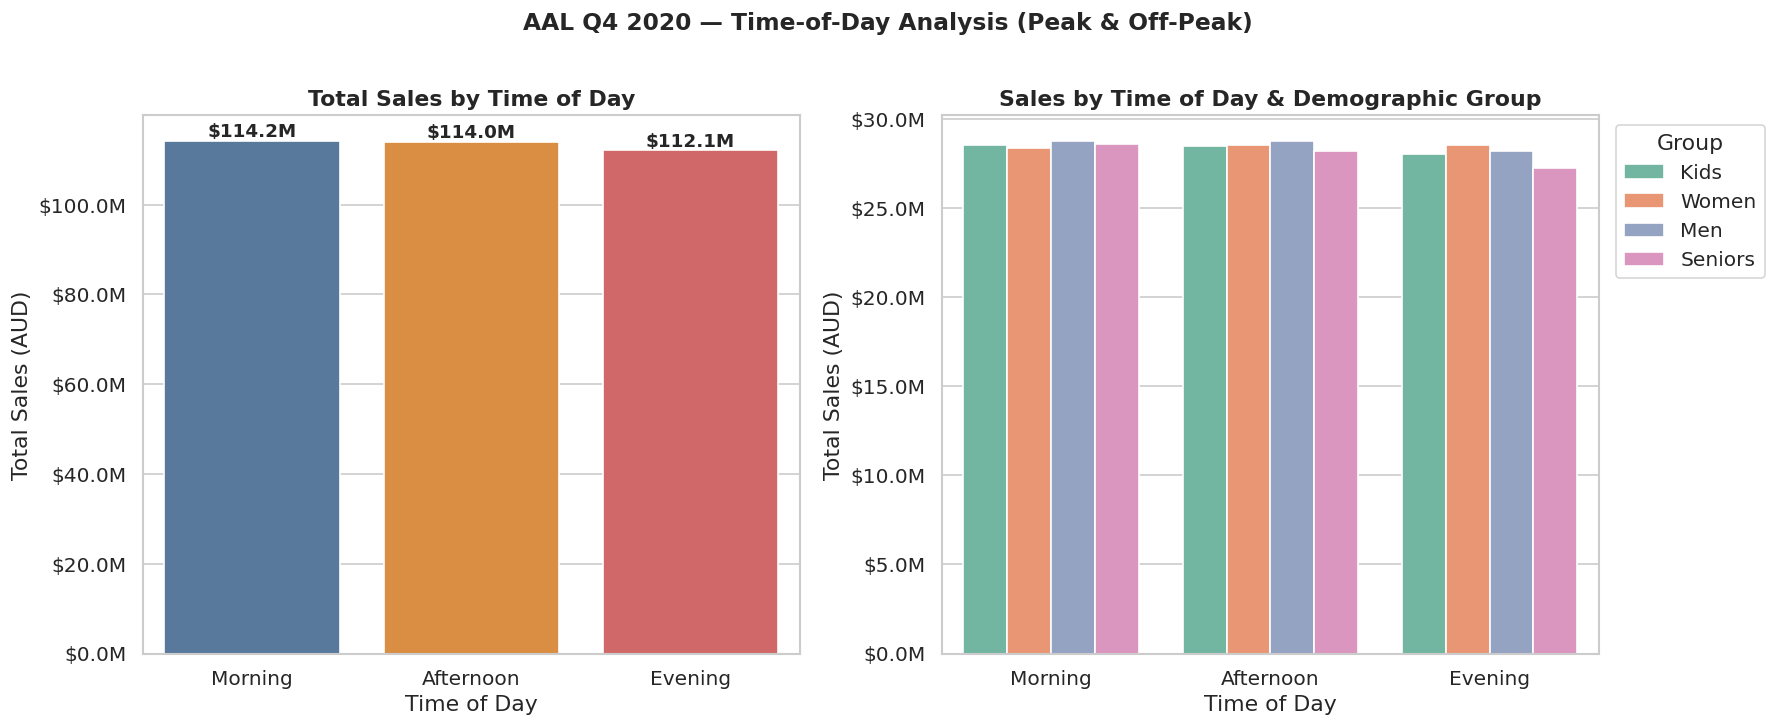

Peak Sales Period : Morning
Off-Peak Period   : Evening


In [40]:

time_order = ['Morning', 'Afternoon', 'Evening']

df['Time'] = df_raw['Time'].str.strip()

#Time-of-Day Analysis
# Grouping and calculating totals/means
time_sales = (df.groupby('Time', observed=True)['Sales']
                .agg(['sum', 'mean']).reset_index())
time_group = (df.groupby(['Time', 'Group'], observed=True)['Sales']
                .sum().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Total Sales by Time of Day
sns.barplot(data=time_sales, x='Time', y='sum',
            palette=['#4e79a7','#f28e2b','#e15759'],
            order=time_order, ax=axes[0])
axes[0].set_title('Total Sales by Time of Day', fontweight='bold')
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('Total Sales (AUD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

for bar in axes[0].patches:
    axes[0].annotate(f"${bar.get_height()/1e6:.1f}M",
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Sales by Time and Demographic Group
sns.barplot(data=time_group, x='Time', y='Sales', hue='Group',
            palette='Set2', order=time_order,
            hue_order=['Kids','Women','Men','Seniors'], ax=axes[1])
axes[1].set_title('Sales by Time of Day & Demographic Group', fontweight='bold')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Total Sales (AUD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].legend(title='Group', bbox_to_anchor=(1.01, 1))

plt.suptitle('AAL Q4 2020 — Time-of-Day Analysis (Peak & Off-Peak)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Find peak and low slots only if data is present
if not time_sales.empty:
    peak_slot = time_sales.loc[time_sales['sum'].idxmax(), 'Time']
    low_slot  = time_sales.loc[time_sales['sum'].idxmin(), 'Time']
    print(f"Peak Sales Period : {peak_slot}")
    print(f"Off-Peak Period   : {low_slot}")
else:
    print("Error: No data found for Time-of-Day analysis.")

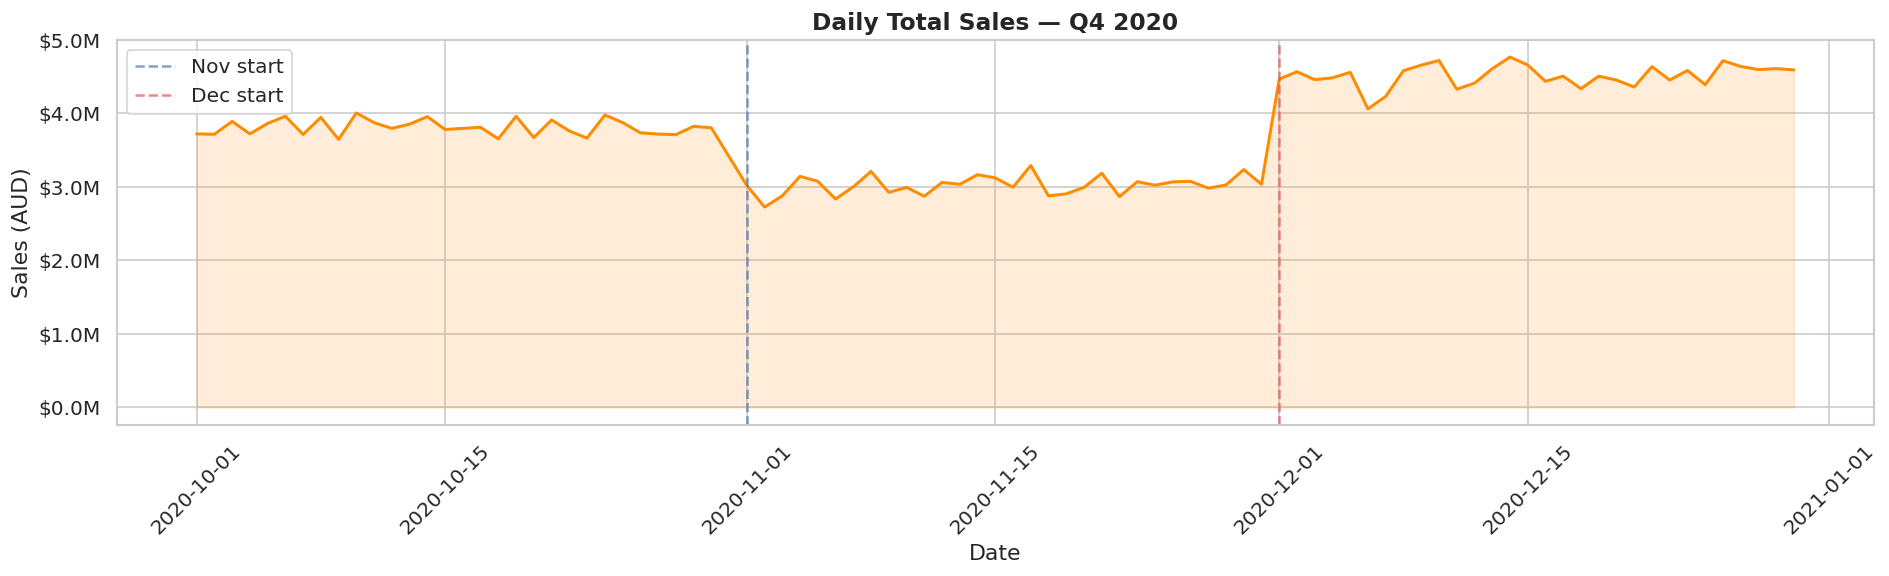

In [41]:
# Daily Sales Trend
daily = df.groupby('Date')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
sns.lineplot(data=daily, x='Date', y='Sales',
             color='darkorange', linewidth=1.8, ax=ax)
ax.fill_between(daily['Date'], daily['Sales'], alpha=0.15, color='darkorange')
ax.set_title('Daily Total Sales — Q4 2020', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (AUD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for mo, col, label in zip([11, 12],
                           ['#4e79a7', '#e15759'],
                           ['Nov start', 'Dec start']):
    ax.axvline(pd.Timestamp(f'2020-{mo:02d}-01'), color=col,
               linestyle='--', alpha=0.7, label=label)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

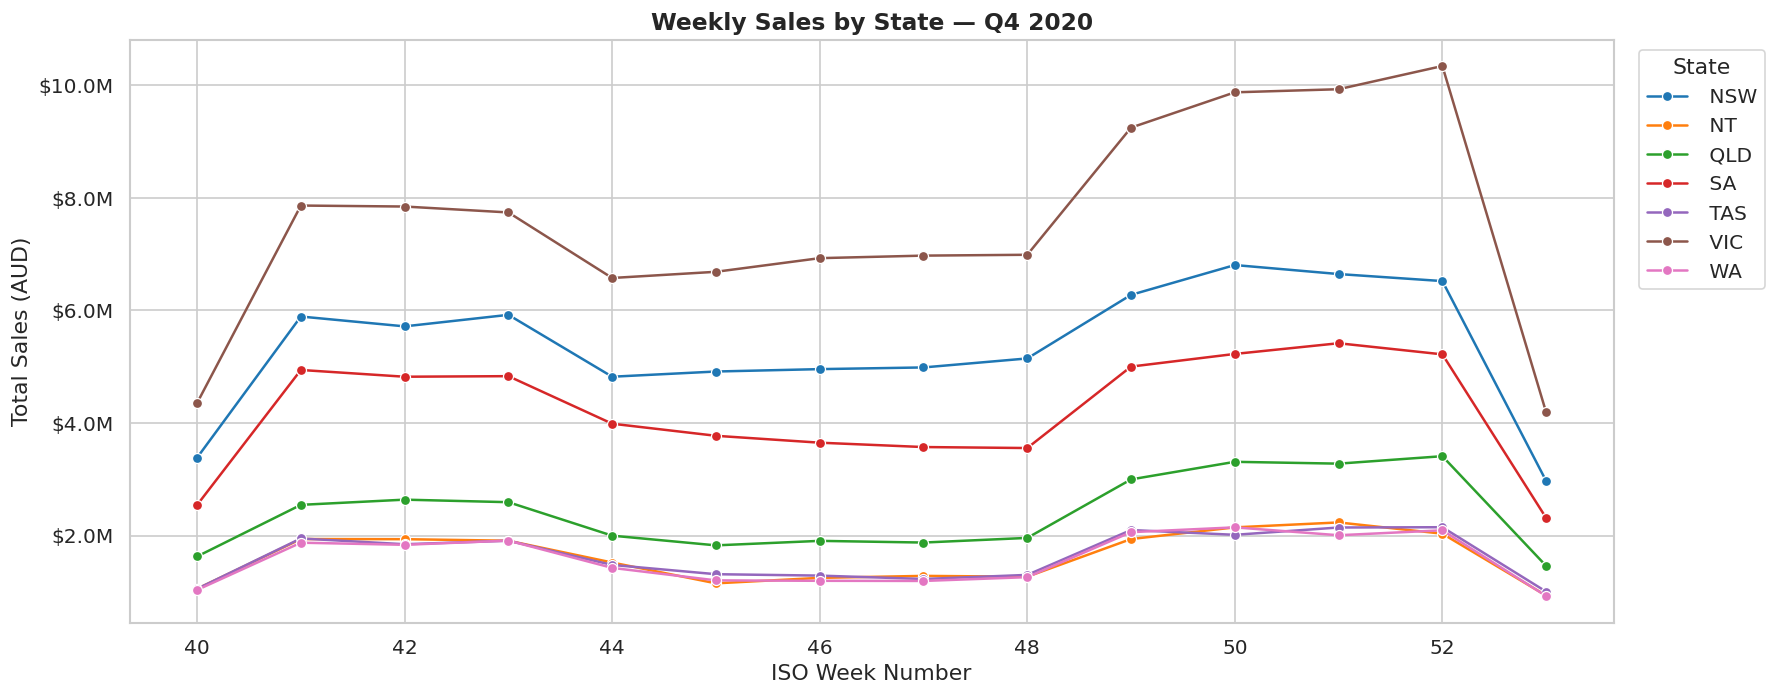

In [42]:
# Weekly Sales by State
weekly_state = (df.groupby(['Week', 'State'])['Sales'].sum().reset_index())

fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(data=weekly_state, x='Week', y='Sales',
             hue='State', marker='o', palette='tab10', ax=ax)
ax.set_title('Weekly Sales by State — Q4 2020', fontsize=14, fontweight='bold')
ax.set_xlabel('ISO Week Number')
ax.set_ylabel('Total Sales (AUD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(title='State', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

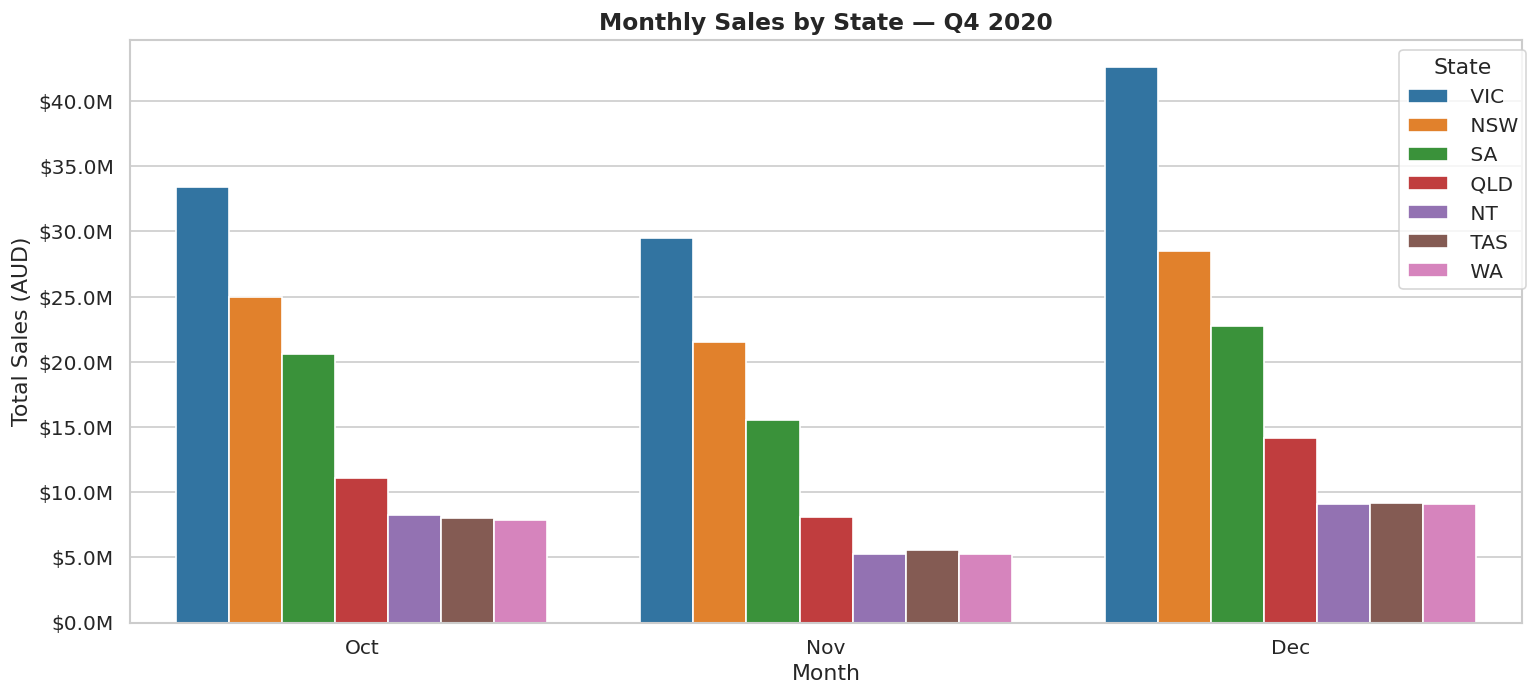

In [44]:
# Monthly Sales by State
month_cat = pd.CategoricalDtype(['Oct', 'Nov', 'Dec'], ordered=True)
monthly_state['MonthName'] = monthly_state['MonthName'].astype(month_cat)
monthly_state = monthly_state.sort_values('MonthName')

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=monthly_state, x='MonthName', y='Sales',
            hue='State', palette='tab10', ax=ax)
ax.set_title('Monthly Sales by State — Q4 2020', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (AUD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(title='State', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

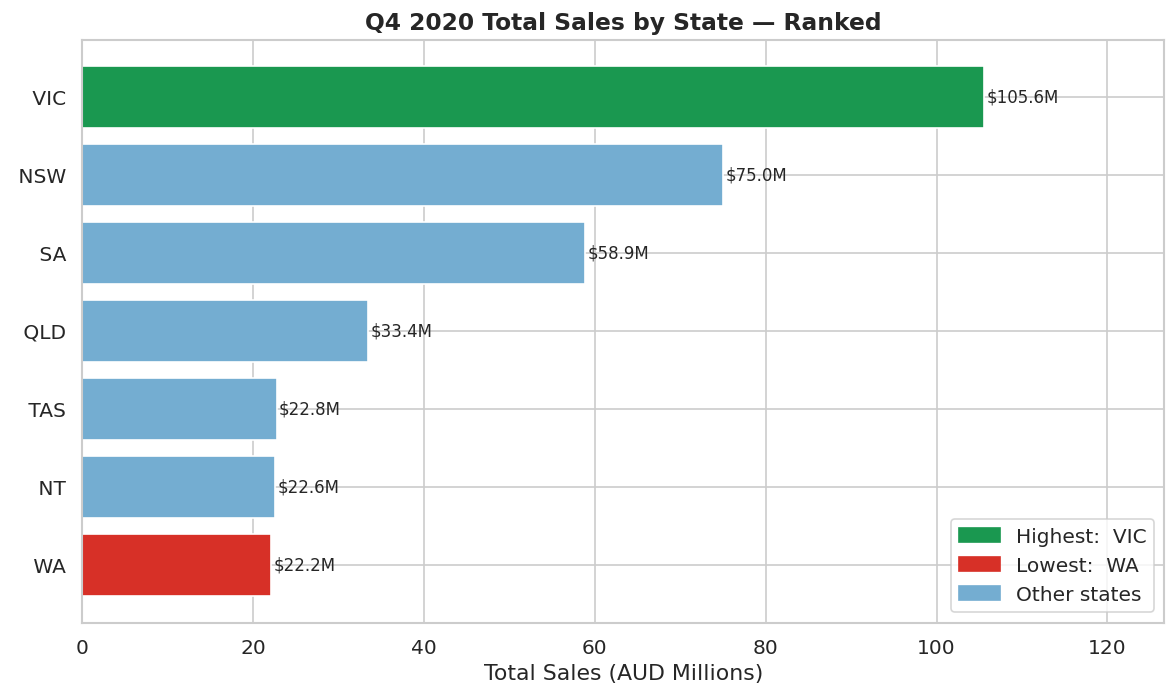

In [46]:
# Quarterly State Ranking (Horizontal Bar)
q_sorted = quarterly.sort_values('Q4_Sales')
colors = ['#d73027' if s == low_state else
          '#1a9850' if s == high_state else '#74add1'
          for s in q_sorted['State']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(q_sorted['State'], q_sorted['Q4_Sales'] / 1e6, color=colors)
ax.set_title('Q4 2020 Total Sales by State — Ranked',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales (AUD Millions)')
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():.1f}M', va='center', fontsize=10)
ax.set_xlim(0, q_sorted['Q4_Sales'].max() / 1e6 * 1.2)
from matplotlib.patches import Patch
legend_els = [Patch(color='#1a9850', label=f'Highest: {high_state}'),
              Patch(color='#d73027', label=f'Lowest: {low_state}'),
              Patch(color='#74add1', label='Other states')]
ax.legend(handles=legend_els, loc='lower right')
plt.tight_layout()
plt.show()

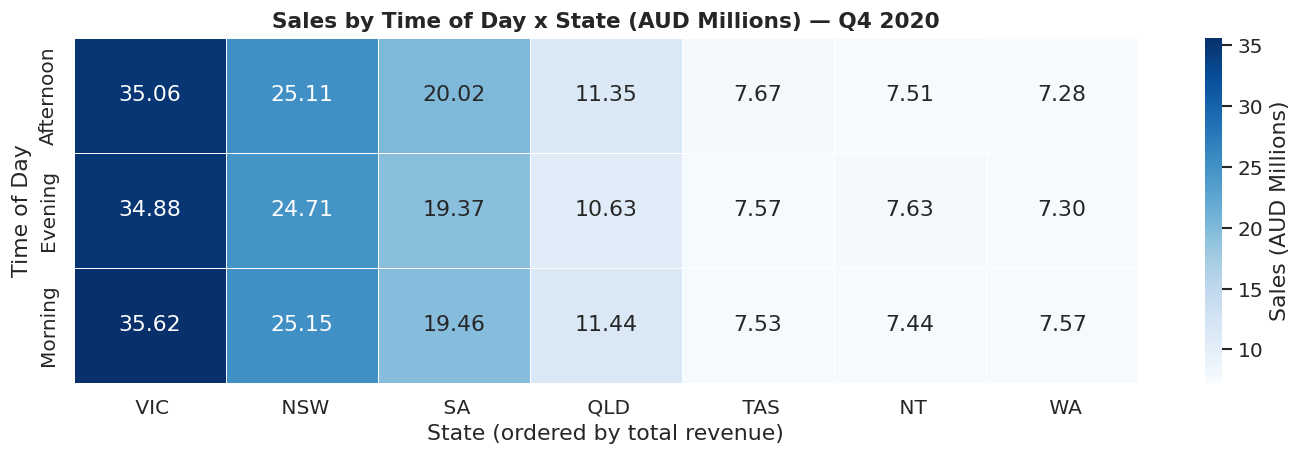

In [48]:
# Time x State Heatmap
time_state = (df.groupby(['Time', 'State'], observed=True)['Sales']
                .sum().unstack()[state_order])

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(time_state / 1e6, annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Sales (AUD Millions)'})
ax.set_title('Sales by Time of Day x State (AUD Millions) — Q4 2020',
             fontsize=13, fontweight='bold')
ax.set_xlabel('State (ordered by total revenue)')
ax.set_ylabel('Time of Day')
plt.tight_layout()
plt.show()

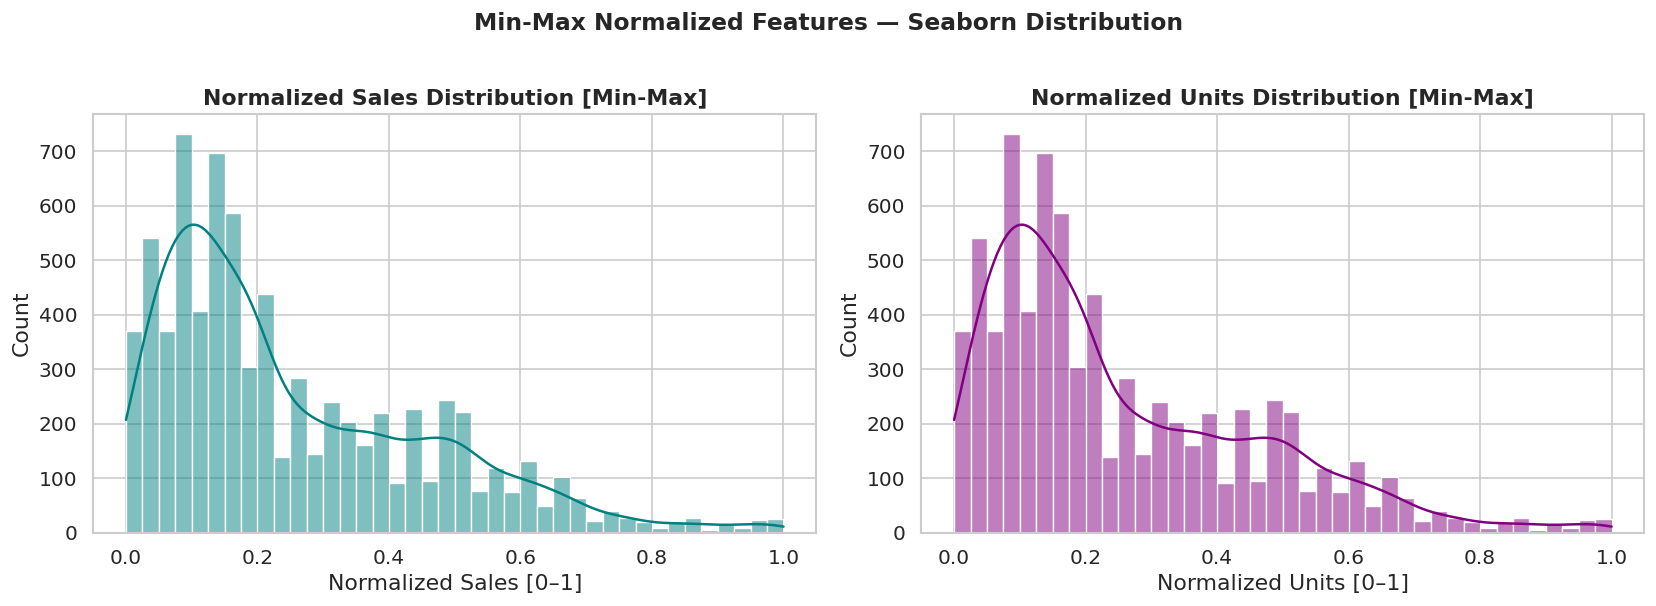

In [50]:
# Normalized Sales Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df, x='Sales_norm', kde=True, color='teal', bins=40, ax=axes[0])
axes[0].set_title('Normalized Sales Distribution [Min-Max]', fontweight='bold')
axes[0].set_xlabel('Normalized Sales [0–1]')

sns.histplot(df, x='Unit_norm', kde=True, color='purple', bins=40, ax=axes[1])
axes[1].set_title('Normalized Units Distribution [Min-Max]', fontweight='bold')
axes[1].set_xlabel('Normalized Units [0–1]')

plt.suptitle('Min-Max Normalized Features — Seaborn Distribution',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

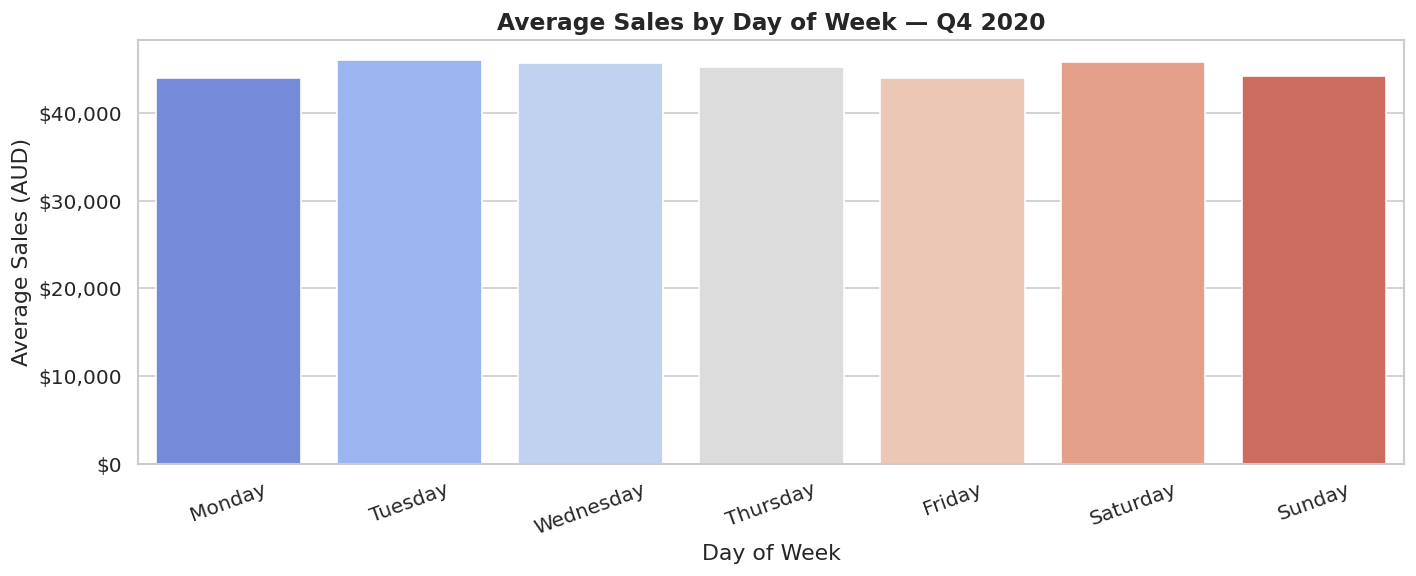

In [51]:
# Day-of-Week Sales Pattern
dow_order = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']
dow_sales = (df.groupby('DOW')['Sales']
               .mean().reindex(dow_order).reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=dow_sales, x='DOW', y='Sales',
            palette='coolwarm', ax=ax)
ax.set_title('Average Sales by Day of Week — Q4 2020',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Sales (AUD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

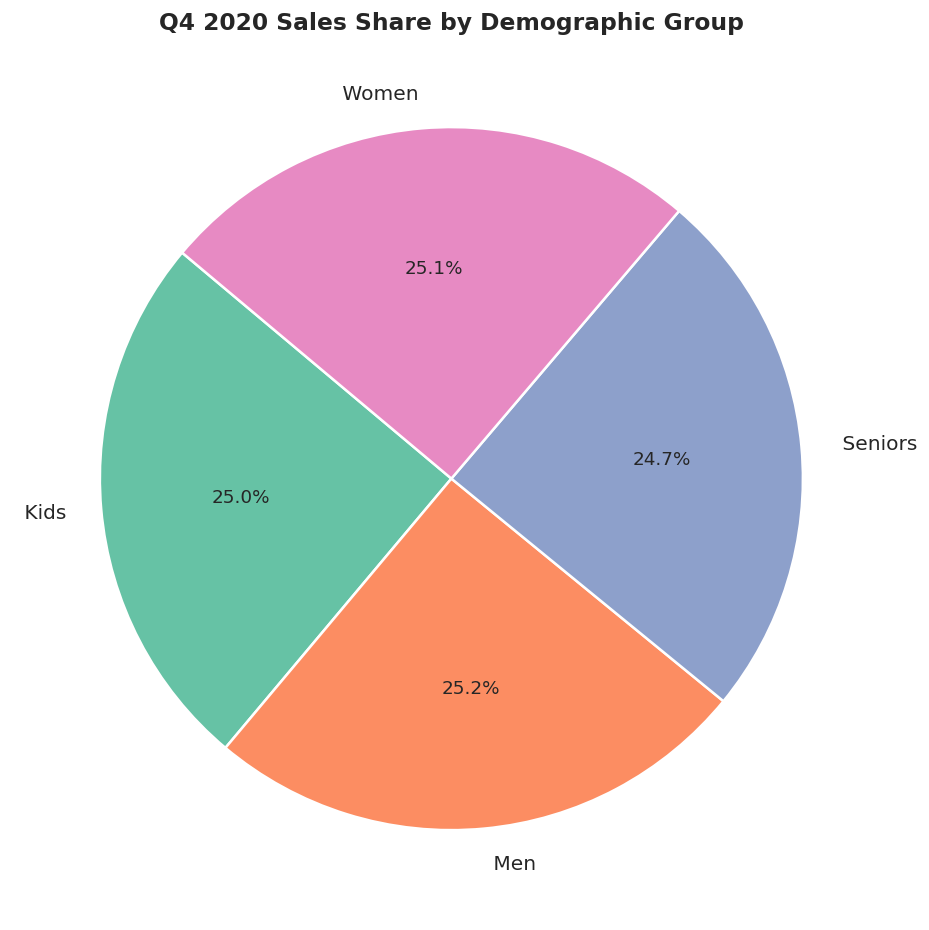

In [52]:
# Group Sales Share (Pie)
group_share = group_total.set_index('Group')['Sales']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    group_share, labels=group_share.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('Set2', 4),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
for at in autotexts:
    at.set_fontsize(11)
ax.set_title('Q4 2020 Sales Share by Demographic Group',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#**FINAL SUMMARY INSIGHTS**

In [53]:
state_rank = state_total.sort_values('Sales', ascending=False).reset_index(drop=True)
group_rank = group_total.sort_values('Sales', ascending=False).reset_index(drop=True)

print("\n" + "="*62)
print("     AAL Q4 2020 — KEY INSIGHTS FOR S&M HEAD")
print("="*62)
print(f"  Dataset : 7,560 transactions | 7 states | 3 time slots")
print(f"  Period  : 1 Oct – 30 Dec 2020 (Q4, 90 days)")
print("-"*62)
print("  STATE RANKINGS (highest to lowest Q4 revenue):")
medals = ['[1st]','[2nd]','[3rd]','[4th]','[5th]','[6th]','[7th]']
for i, row in state_rank.iterrows():
    print(f"  {medals[i]} {row['State']:<5}  AUD {row['Sales']/1e6:.2f}M")
print("-"*62)
print("  GROUP RANKINGS (highest to lowest Q4 revenue):")
for i, row in group_rank.iterrows():
    print(f"  {medals[i]} {row['Group']:<8}  AUD {row['Sales']/1e6:.2f}M")
print("-"*62)
print(f"  PEAK SALES PERIOD : {peak_slot}")
print(f"  OFF-PEAK PERIOD   : {low_slot}")
print("-"*62)
print("  RECOMMENDATIONS:")
print(f"  * Prioritise expansion investment in {state_rank.iloc[0]['State']} and {state_rank.iloc[1]['State']}")
print(f"  * Design targeted sales programs for {low_state} (lowest revenue)")
print(f"  * Deploy hyper-personalisation & Next Best Offers")
print(f"    during {peak_slot} to maximise conversion rates")
print(f"  * {low_group} segment is underperforming — launch loyalty")
print(f"    campaigns and tailored product bundles")
print("  * December holiday spike: pre-load inventory by mid-Nov")
print("="*62)


     AAL Q4 2020 — KEY INSIGHTS FOR S&M HEAD
  Dataset : 7,560 transactions | 7 states | 3 time slots
  Period  : 1 Oct – 30 Dec 2020 (Q4, 90 days)
--------------------------------------------------------------
  STATE RANKINGS (highest to lowest Q4 revenue):
  [1st]  VIC   AUD 105.56M
  [2nd]  NSW   AUD 74.97M
  [3rd]  SA    AUD 58.86M
  [4th]  QLD   AUD 33.42M
  [5th]  TAS   AUD 22.76M
  [6th]  NT    AUD 22.58M
  [7th]  WA    AUD 22.15M
--------------------------------------------------------------
  GROUP RANKINGS (highest to lowest Q4 revenue):
  [1st]  Men      AUD 85.75M
  [2nd]  Women    AUD 85.44M
  [3rd]  Kids     AUD 85.07M
  [4th]  Seniors  AUD 84.04M
--------------------------------------------------------------
  PEAK SALES PERIOD : Morning
  OFF-PEAK PERIOD   : Evening
--------------------------------------------------------------
  RECOMMENDATIONS:
  * Prioritise expansion investment in  VIC and  NSW
  * Design targeted sales programs for  WA (lowest revenue)
  * Deploy